In [1]:
from pathlib import Path
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit  # Logistic function

# 1. BASE DIRECTORY 

BASE = Path.home() / "Desktop" / "LCS_eligibility_Ireland"

CODE_DIR = BASE / "code"
RAW_DIR = BASE / "data_raw"
PROC_DIR = BASE / "data_processed"
OUT_DIR = BASE / "output"

print("Using base directory:", BASE)

Using base directory: C:\Users\tatianabezdenezhnykh\Desktop\LCS_eligibility_Ireland


In [2]:


# Load the raw .dta 
file_path = RAW_DIR/ "eurobarometer2017.dta"
data = pd.read_stata(file_path)



# Keep only relevant columns
cols_to_keep = [
    "survey", "uniqid", "qb1", "qb3", "qb5a", "qb5b", "qb2a",
    "d10", "d11", "p7ie", "d63", "d7", "d8r2", "d25"
]
data = data[[col for col in data.columns if col in cols_to_keep]]

# Add survey wave year
data["wave"] = 2017

# Rename columns
data = data.rename(columns={
    "qb1": "sm_status",
    "qb3": "age_stop",
    "qb2a": "age_start",
    "qb5a": "cig_day_current",
    "qb5b": "cig_day_past",
    "d7": "marital_st",
    "d8r2": "educ",
    "d10": "gender",
    "d11": "age_years",
    "d25": "commun",
    "d63": "soc_class",
    "p7ie": "region_ir"
})

# Recode cig_day
data["cig_day_current"] = data["cig_day_current"].replace({996: pd.NA, 997: pd.NA, 998: pd.NA})
data["cig_day_past"] = data["cig_day_past"].replace({996: pd.NA})

# Recode marital status
data["marital_st"] = data["marital_st"].replace({
    9: 1, 10: 1,
    1: 2, 2: 2, 3: 2, 4: 2, 5: 2, 6: 2, 7: 2, 8: 2,
    11: 3, 12: 3,
    13: 4, 14: 4
})

# Recode education and soc_class
data["educ"] = data["educ"].replace({10: 4, 11: 5})
data["soc_class"] = data["soc_class"].replace({1: 1, 2: 1, 3: 2, 4: 3, 5: 3, 7: pd.NA, 8: pd.NA, 9: pd.NA})

# Apply labels
educ_lbl = {
    1: "Less the 15 years", 2: "16-19 years", 3: "20 years and older",
    4: "Still studying", 5: "No full-time education"
}
soc_class_lbl = {1: "Low", 2: "Middle", 3: "High"}
marital_lbl = {
    1: "Unmarried", 2: "(Re-)Married/Single with partner",
    3: "Divorced or separated", 4: "Widowed"
}
region_lbl = {
    1: "Border", 2: "West", 3: "Mid-West", 4: "South-East", 5: "South-West",
    6: "Dublin", 7: "Mid-East", 8: "Midland", 9: "Rest of Leinster",
    10: " Munster ", 11: "Connacht / Connaught & Ulster"
}

data["educ"] = data["educ"].map(educ_lbl)
data["soc_class"] = data["soc_class"].map(soc_class_lbl)
data["marital_st"] = data["marital_st"].map(marital_lbl)
data["region_ir"] = data["region_ir"].map(region_lbl)

# Reorder columns
col_order = [
    "wave", "survey", "uniqid", "sm_status", "age_start", "age_stop",
    "cig_day_past", "cig_day_current", "gender", "age_years", "educ",
    "marital_st", "soc_class", "region_ir", "commun"
]
data = data[[col for col in col_order if col in data.columns]]

# Show result
data.head()


,wave,survey,uniqid,sm_status,age_start,age_stop,cig_day_past,cig_day_current,gender,age_years,educ,marital_st,soc_class,region_ir,commun
0,2017,Eurobarometer 87.1 (March 2017),16442029,You have never smoked,NaN,NaN,NaN,NaN,Woman,32,NaN,NaN,NaN,NaN,Small or middle sized town
1,2017,Eurobarometer 87.1 (March 2017),16442030,You used to smoke but you have stopped,12.0,16.0,5.0,NaN,Woman,47,NaN,NaN,NaN,NaN,Rural area or village
2,2017,Eurobarometer 87.1 (March 2017),16442031,You used to smoke but you have stopped,14.0,16.0,10.0,NaN,Man,17,NaN,NaN,NaN,NaN,Rural area or village
3,2017,Eurobarometer 87.1 (March 2017),16447491,You have never smoked,NaN,NaN,NaN,NaN,Man,20,NaN,NaN,NaN,NaN,Small or middle sized town
4,2017,Eurobarometer 87.1 (March 2017),16447492,You currently smoke,18.0,NaN,NaN,20.0,Man,60,NaN,NaN,NaN,NaN,Large town


In [3]:
# Reformat `sm_status` into numeric codes
status_mapping = {
    "You currently smoke": 1,
    "You have never smoked": 2,
    "You used to smoke but you have stopped": 3
}

# Map smoking status to numeric codes
data['sm_status_code'] = data['sm_status'].map(status_mapping)

# Convert columns to numeric
numeric_columns = ['age_years', 'age_stop', 'age_start']
data[numeric_columns] = data[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Calculate tie since quitting for quitters
data['time_since_quit'] = data.apply(
    lambda row: row['age_years'] - row['age_stop'] if row['sm_status_code'] == 3 else None, axis=1
)

# Calculate time since starting for smokers
data['time_since_start'] = data.apply(
    lambda row: row['age_years'] - row['age_start'] if row['sm_status_code'] == 1 else None, axis=1
)

# Quick check
data[['sm_status', 'sm_status_code', 'age_years', 'age_start', 'age_stop', 'time_since_quit', 'time_since_start']].head()


,sm_status,sm_status_code,age_years,age_start,age_stop,time_since_quit,time_since_start
0,You have never smoked,2,32.0,NaN,NaN,NaN,NaN
1,You used to smoke but you have stopped,3,47.0,12.0,16.0,31.0,NaN
2,You used to smoke but you have stopped,3,17.0,14.0,16.0,1.0,NaN
3,You have never smoked,2,20.0,NaN,NaN,NaN,NaN
4,You currently smoke,1,60.0,18.0,NaN,NaN,42.0


In [4]:
import pandas as pd

# Ensure age_years is numeric
data['age_years'] = pd.to_numeric(data['age_years'], errors='coerce')

# Define the bins and labels for 5-year age groups
age_bins = [0, 14, 19, 24, 29, 34, 39, 44, 49, 54, 59, 64, 69, 74, 79, 84, 89, 94, 99, float('inf')]
age_labels = [
    '0-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54',
    '55-59', '60-64', '65-69', '70-74', '75-79', '80-84', '85-89', '90-94', '95-99', '100+'
]

# Create the new age_group column
data['age_group'] = pd.cut(data['age_years'], bins=age_bins, labels=age_labels, right=False)

# check the distribution
print(data['age_group'].value_counts().sort_index())


age_group
0-14        0
15-19     663
20-24    1361
25-29    1693
30-34    1850
35-39    2046
40-44    2164
45-49    2202
50-54    2272
55-59    2456
60-64    2687
65-69    2718
70-74    2386
75-79    1671
80-84    1009
85-89     439
90-94     135
95-99      15
100+        0
Name: count, dtype: int64


In [5]:
data.head()

,wave,survey,uniqid,sm_status,age_start,age_stop,cig_day_past,cig_day_current,gender,age_years,educ,marital_st,soc_class,region_ir,commun,sm_status_code,time_since_quit,time_since_start,age_group
0,2017,Eurobarometer 87.1 (March 2017),16442029,You have never smoked,NaN,NaN,NaN,NaN,Woman,32.0,NaN,NaN,NaN,NaN,Small or middle sized town,2,NaN,NaN,30-34
1,2017,Eurobarometer 87.1 (March 2017),16442030,You used to smoke but you have stopped,12.0,16.0,5.0,NaN,Woman,47.0,NaN,NaN,NaN,NaN,Rural area or village,3,31.0,NaN,45-49
2,2017,Eurobarometer 87.1 (March 2017),16442031,You used to smoke but you have stopped,14.0,16.0,10.0,NaN,Man,17.0,NaN,NaN,NaN,NaN,Rural area or village,3,1.0,NaN,15-19
3,2017,Eurobarometer 87.1 (March 2017),16447491,You have never smoked,NaN,NaN,NaN,NaN,Man,20.0,NaN,NaN,NaN,NaN,Small or middle sized town,2,NaN,NaN,20-24
4,2017,Eurobarometer 87.1 (March 2017),16447492,You currently smoke,18.0,NaN,NaN,20.0,Man,60.0,NaN,NaN,NaN,NaN,Large town,1,NaN,42.0,60-64


In [6]:
# Define age group mapping from earlier (remove 'years', correct 95+ to 90+)
age_bins = [0, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, float("inf")]
age_labels = [
    '0 - 14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49',
    '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80-84', '85-89', '90 and over'
]

# Apply age group categorization to the dataset
data["age_group"] = pd.cut(data["age_years"], bins=age_bins, labels=age_labels, right=False)

# Now reuse previous logic to get stats for quitters by age group
former_smokers = data[data["sm_status"] == "You used to smoke but you have stopped"].copy()
former_smokers["years_since_quit"] = data["age_years"] - former_smokers["age_stop"]

# Group by age_group and compute counts
age_group_stats = former_smokers.groupby("age_group").apply(
    lambda df: pd.Series({
        "Total Former": len(df),
        "Quit <10": (df["years_since_quit"] < 10).sum(),
        "Quit <15": (df["years_since_quit"] < 15).sum()
    })
).reset_index()

# Calculate percentages
age_group_stats["% Quit <10"] = round((age_group_stats["Quit <10"] / age_group_stats["Total Former"]) * 100, 2)
age_group_stats["% Quit <15"] = round((age_group_stats["Quit <15"] / age_group_stats["Total Former"]) * 100, 2)

age_group_stats.head(20)


C:\Users\tatianabezdenezhnykh\AppData\Local\Temp\ipykernel_10580\1092395101.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_stats = former_smokers.groupby("age_group").apply(
C:\Users\tatianabezdenezhnykh\AppData\Local\Temp\ipykernel_10580\1092395101.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  age_group_stats = former_smokers.groupby("age_group").apply(


,age_group,Total Former,Quit <10,Quit <15,% Quit <10,% Quit <15
0,0 - 14,0,0,0,NaN,NaN
1,15-19,36,35,35,97.22,97.22
2,20-24,129,128,128,99.22,99.22
3,25-29,224,203,219,90.62,97.77
4,30-34,321,249,303,77.57,94.39
5,35-39,387,242,331,62.53,85.53
6,40-44,381,177,273,46.46,71.65
7,45-49,426,161,250,37.79,58.69
8,50-54,457,192,272,42.01,59.52
9,55-59,599,186,280,31.05,46.74


In [7]:

#Calculate quitting rate
quitters_recent = data[(data['sm_status_code'] == 3) & (data['time_since_quit'] == 0)]
smokers = data[data['sm_status_code'] == 1]

quitting_rate = (
    quitters_recent.groupby(['age_group']).size() /
    smokers.groupby(['age_group']).size()
).reset_index(name='quitting_rate')

# Calculate initiation rate
starters_recent = data[(data['sm_status_code'] == 1) & (data['time_since_start'] == 0)]
non_smokers = data[data['sm_status_code'] == 2]

initiation_rate = (
    starters_recent.groupby(['age_group']).size() /
    non_smokers.groupby(['age_group']).size()
).reset_index(name='initiation_rate')

# Preview both rates
print(quitting_rate)
print(initiation_rate)


      age_group  quitting_rate
0        0 - 14            NaN
1         15-19       0.073394
2         20-24       0.045187
3         25-29       0.030252
4         30-34       0.039152
5         35-39       0.042857
6         40-44       0.020440
7         45-49       0.016713
8         50-54       0.032070
9         55-59       0.021651
10        60-64       0.030945
11        65-69       0.014706
12        70-74       0.031008
13        75-79       0.012579
14        80-84       0.000000
15        85-89       0.083333
16  90 and over       0.000000
      age_group  initiation_rate
0        0 - 14              NaN
1         15-19         0.020896
2         20-24         0.003906
3         25-29         0.001093
4         30-34         0.001060
5         35-39         0.002933
6         40-44         0.000000
7         45-49         0.000910
8         50-54         0.000000
9         55-59         0.000870
10        60-64         0.000799
11        65-69         0.000000
12        70-

C:\Users\tatianabezdenezhnykh\AppData\Local\Temp\ipykernel_10580\730774763.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quitters_recent.groupby(['age_group']).size() /
C:\Users\tatianabezdenezhnykh\AppData\Local\Temp\ipykernel_10580\730774763.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  smokers.groupby(['age_group']).size()
C:\Users\tatianabezdenezhnykh\AppData\Local\Temp\ipykernel_10580\730774763.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the

In [8]:


# Reload cleaned Eurobarometer data
df = data

# Create binary outcome variables
df["quit_recently"] = ((df["sm_status_code"] == 3) & (df["time_since_quit"] == 0)).astype(int)
df["started_recently"] = ((df["sm_status_code"] == 1) & (df["time_since_start"] == 0)).astype(int)

# Filter relevant subgroups for modeling
quit_model_data = df[df["sm_status_code"].isin([1, 3])]  # Smokers and quitters
init_model_data = df[df["sm_status_code"].isin([1, 2])]  # Smokers and never smokers

# Convert categorical variables
quit_model_data["gender"] = quit_model_data["gender"].astype("category")
init_model_data["gender"] = init_model_data["gender"].astype("category")

# Logistic regression for quitting
quit_model = smf.logit("quit_recently ~ age_years + C(gender)", data=quit_model_data).fit(disp=0)

# Logistic regression for initiation
init_model = smf.logit("started_recently ~ age_years + C(gender)", data=init_model_data).fit(disp=0)

quit_model_summary = quit_model.summary2().tables[1]
init_model_summary = init_model.summary2().tables[1]

quit_model_summary, init_model_summary



C:\Users\tatianabezdenezhnykh\AppData\Local\Temp\ipykernel_10580\1879817744.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  quit_model_data["gender"] = quit_model_data["gender"].astype("category")
C:\Users\tatianabezdenezhnykh\AppData\Local\Temp\ipykernel_10580\1879817744.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  init_model_data["gender"] = init_model_data["gender"].astype("category")


(                       Coef.  Std.Err.          z         P>|z|    [0.025  \
 Intercept          -2.551055  0.209154 -12.196996  3.225043e-34 -2.960991   
 C(gender)[T.Woman]  0.014197  0.140623   0.100957  9.195843e-01 -0.261420   
 age_years          -0.033893  0.004332  -7.823667  5.130642e-15 -0.042383   
 
                       0.975]  
 Intercept          -2.141120  
 C(gender)[T.Woman]  0.289814  
 age_years          -0.025402  ,
                        Coef.  Std.Err.         z         P>|z|    [0.025  \
 Intercept          -2.833989  0.556733 -5.090396  3.573174e-07 -3.925165   
 C(gender)[T.Woman] -0.746178  0.414102 -1.801920  7.155798e-02 -1.557803   
 age_years          -0.097261  0.018858 -5.157541  2.502146e-07 -0.134222   
 
                       0.975]  
 Intercept          -1.742813  
 C(gender)[T.Woman]  0.065446  
 age_years          -0.060300  )

In [9]:

# Coefficients from quitting model (replace with actual coefficients from your model)
quit_intercept = -2.5511
quit_age_coef = -0.0339
quit_gender_coef = 0.0142  # for Woman

# Coefficients from initiation model (replace with actual coefficients from your model)
init_intercept = -2.8340
init_age_coef = -0.0973
init_gender_coef = -0.7462  # for Woman

# Define age range
ages = np.arange(15, 81)

# Estimate probabilities for Men (gender_coef = 0)
quit_prob_men = 1 / (1 + np.exp(-(quit_intercept + quit_age_coef * ages)))
init_prob_men = 1 / (1 + np.exp(-(init_intercept + init_age_coef * ages)))

# Estimate probabilities for Women
quit_prob_women = 1 / (1 + np.exp(-(quit_intercept + quit_gender_coef + quit_age_coef * ages)))
init_prob_women = 1 / (1 + np.exp(-(init_intercept + init_gender_coef + init_age_coef * ages)))

# Create DataFrame with results
prob_df = pd.DataFrame({
    'age': ages,
    'quit_prob_men': quit_prob_men,
    'quit_prob_women': quit_prob_women,
    'init_prob_men': init_prob_men,
    'init_prob_women': init_prob_women
})

print(prob_df)

    age  quit_prob_men  quit_prob_women  init_prob_men  init_prob_women
0    15       0.044805         0.045416       0.013473         0.006434
1    16       0.043376         0.043969       0.012239         0.005841
2    17       0.041991         0.042566       0.011117         0.005302
3    18       0.040648         0.041206       0.010097         0.004813
4    19       0.039347         0.039887       0.009169         0.004369
..  ...            ...              ...            ...              ...
61   76       0.005896         0.005980       0.000036         0.000017
62   77       0.005701         0.005782       0.000033         0.000016
63   78       0.005512         0.005590       0.000030         0.000014
64   79       0.005329         0.005405       0.000027         0.000013
65   80       0.005153         0.005226       0.000024         0.000012

[66 rows x 5 columns]


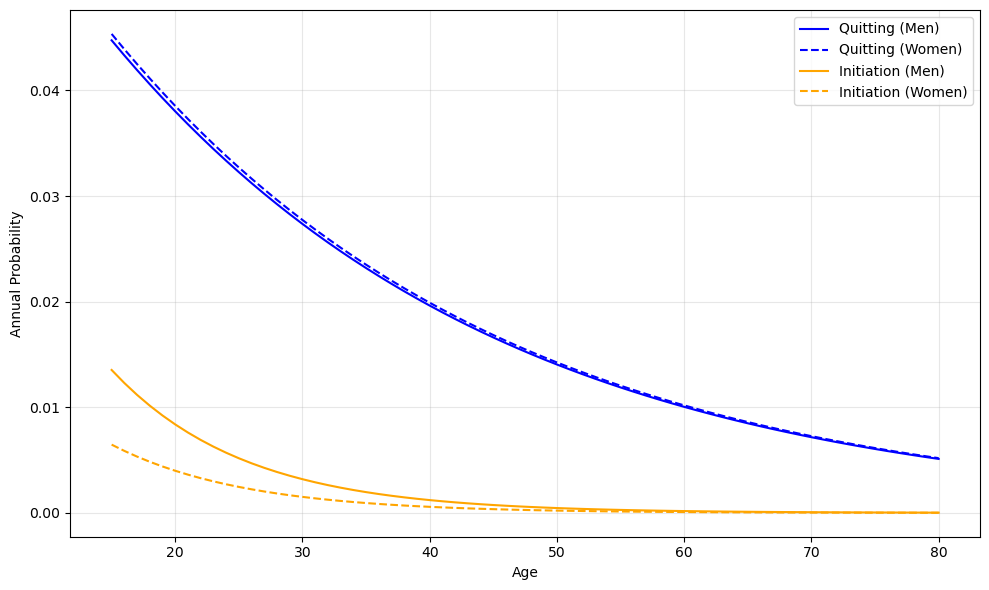

In [10]:
# Define age range
age_range = np.arange(15, 81)

# Quitting model coefficients
intercept_quit = -2.551
coef_age_quit = -0.034
coef_gender_quit = 0.014

# Initiation model coefficients
intercept_init = -2.834
coef_age_init = -0.097
coef_gender_init = -0.746

# Compute probabilities using logistic function (sigmoid)
def compute_logistic_prob(intercept, coef_age, coef_gender, gender):
    gender_val = 1 if gender == "Woman" else 0
    return expit(intercept + coef_age * age_range + coef_gender * gender_val)

# Calculate probabilities
prob_quit_men = compute_logistic_prob(intercept_quit, coef_age_quit, coef_gender_quit, "Man")
prob_quit_women = compute_logistic_prob(intercept_quit, coef_age_quit, coef_gender_quit, "Woman")
prob_init_men = compute_logistic_prob(intercept_init, coef_age_init, coef_gender_init, "Man")
prob_init_women = compute_logistic_prob(intercept_init, coef_age_init, coef_gender_init, "Woman")

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(age_range, prob_quit_men, label='Quitting (Men)', color='blue', linestyle='-')
plt.plot(age_range, prob_quit_women, label='Quitting (Women)', color='blue', linestyle='--')
plt.plot(age_range, prob_init_men, label='Initiation (Men)', color='orange', linestyle='-')
plt.plot(age_range, prob_init_women, label='Initiation (Women)', color='orange', linestyle='--')

# Styling
plt.xlabel('Age')
plt.ylabel('Annual Probability')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

file_path = OUT_DIR  /"transition_rates_plot.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')
plt.show()


In [11]:

# Define 5-year bins and labels
bins = list(range(15, 86, 5))
labels = [f"{a}-{a+4}" for a in bins[:-1]]

# Assign age group
prob_df['age_group'] = pd.cut(prob_df['age'], bins=bins, labels=labels, right=False)

# Group by age group and calculate mean for each transition probability
grouped= prob_df.groupby('age_group').agg({
    'quit_prob_men': 'mean',
    'quit_prob_women': 'mean',
    'init_prob_men': 'mean',
    'init_prob_women': 'mean'
}).reset_index()

# Reshape to long format for gender and probabilities
quitting = grouped.melt(id_vars='age_group', value_vars=['quit_prob_men', 'quit_prob_women'],
                        var_name='gender', value_name='quitting_rate')
quitting['gender'] = quitting['gender'].map({'quit_prob_men': 'Man', 'quit_prob_women': 'Woman'})

initiation = grouped.melt(id_vars='age_group', value_vars=['init_prob_men', 'init_prob_women'],
                          var_name='gender', value_name='initiation_rate')
initiation['gender'] = initiation['gender'].map({'init_prob_men': 'Man', 'init_prob_women': 'Woman'})

# Merge the two
transition_rates_new = pd.merge(quitting, initiation, on=['age_group', 'gender'])

C:\Users\tatianabezdenezhnykh\AppData\Local\Temp\ipykernel_10580\1026185198.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped= prob_df.groupby('age_group').agg({


In [12]:
print(transition_rates_new)

   age_group gender  quitting_rate  initiation_rate
0      15-19    Man       0.042033         0.011219
1      20-24    Man       0.035714         0.006928
2      25-29    Man       0.030315         0.004271
3      30-34    Man       0.025710         0.002630
4      35-39    Man       0.021789         0.001618
5      40-44    Man       0.018455         0.000996
6      45-49    Man       0.015623         0.000612
7      50-54    Man       0.013219         0.000377
8      55-59    Man       0.011181         0.000232
9      60-64    Man       0.009454         0.000142
10     65-69    Man       0.007992         0.000088
11     70-74    Man       0.006755         0.000054
12     75-79    Man       0.005707         0.000033
13     80-84    Man       0.005153         0.000024
14     15-19  Woman       0.042609         0.005352
15     20-24  Woman       0.036207         0.003297
16     25-29  Woman       0.030735         0.002030
17     30-34  Woman       0.026069         0.001249
18     35-39

In [13]:
file_path = PROC_DIR / "transition_rates_new.csv"
transition_rates_new.to_csv(file_path, index=False)